In [27]:
import os
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import cantera as ct
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

In [28]:
# ── Config — must match h2o2_NN_toy_R22R26_discrete_*_train.py exactly ────────
YAML_FILE   = 'chem_cti_toy_model_og.yaml'
IDX_R22     = 21   # H2O2(+M) <=> OH + OH (+M)  — falloff
IDX_R26     = 25   # H2O2 + OH <=> HO2 + H2O   — simple Arrhenius
INPUT_DIM   = 4
PARAM_NAMES = ['lnA_R22', 'Ea_R22', 'lnA_R26', 'Ea_R26']
LN_F        = 10       # ln(f) uncertainty factor for A (both reactions)
SIGMA_E     = 2000.0   # cal/mol half-width for Ea (both reactions)
HIDDEN_DIM  = 16

# Zhang Eq. 8 objective hyperparameters
LAMBDA      = 4.0     # regularization weight
NOISE_FLOOR = 1e-6    # clip before log
SIGMA_OB_LN = 0.05   # observational uncertainty in log-space (Burke 2013 Table 2)

T_INITIAL  = 1057
P_INITIAL  = 1.83 * ct.one_atm
INITIAL_X  = {'H2O2': 860e-6, 'H2O': 663e-6, 'O2': 332e-6,
               'AR':   1.0 - (860+663+332)*1e-6}
DT_MAX     = 1e-6
TIME_STEPS = 6000
T_SIM      = np.linspace(DT_MAX, DT_MAX * TIME_STEPS, TIME_STEPS)

EXP_CSV     = 'Hong et al_Burke.csv'
RESULT_PATH = 'relu_r22r26_discrete_targets.pt'   # switch to relu_r22r26_* to use ReLU model
OUT_PREFIX  = 'opt_r22r26_discrete'

# ── Nominal kinetic parameters from Cantera ────────────────────────────────────
_gas = ct.Solution(YAML_FILE)
_mol = ct.UnitSystem({
    'length': 'cm', 'mass': 'g', 'time': 's',
    'quantity': 'mol', 'pressure': 'dyn / cm^2', 'energy': 'erg',
    'temperature': 'K', 'current': 'A', 'activation-energy': 'cal / mol'})

NOMINAL_A_R22      = _gas.reaction(IDX_R22).rate.low_rate.pre_exponential_factor
NOMINAL_B_R22      = _gas.reaction(IDX_R22).rate.low_rate.temperature_exponent
NOMINAL_EA_R22_si  = _gas.reaction(IDX_R22).rate.low_rate.activation_energy
NOMINAL_EA_R22_cal = _mol.convert_activation_energy_to(f'{NOMINAL_EA_R22_si} J/kmol', 'cal / mol')

NOMINAL_A_R26      = _gas.reaction(IDX_R26).rate.pre_exponential_factor
NOMINAL_B_R26      = _gas.reaction(IDX_R26).rate.temperature_exponent
NOMINAL_EA_R26_si  = _gas.reaction(IDX_R26).rate.activation_energy
NOMINAL_EA_R26_cal = _mol.convert_activation_energy_to(f'{NOMINAL_EA_R26_si} J/kmol', 'cal / mol')

del _gas, _mol

print(f'R22  A={NOMINAL_A_R22:.3e}  B={NOMINAL_B_R22:.2f}  Ea={NOMINAL_EA_R22_cal:.0f} cal/mol')
print(f'R26  A={NOMINAL_A_R26:.3e}  B={NOMINAL_B_R26:.2f}  Ea={NOMINAL_EA_R26_cal:.0f} cal/mol')

R22  A=2.490e+21  B=-2.30  Ea=48749 cal/mol
R26  A=7.590e+10  B=0.00  Ea=7270 cal/mol


In [29]:
# ── Experimental data ─────────────────────────────────────────────────────────
df_exp = pd.read_csv(EXP_CSV)
t_exp  = df_exp['time'].values           # already in seconds
y_exp  = df_exp['x_h2o'].values * 1e-6  # ppm → mole fraction
print(f'Exp: {len(t_exp)} points, '
      f't=[{t_exp.min()*1e3:.3f}, {t_exp.max()*1e3:.3f}] ms, '
      f'H2O=[{y_exp.min()*1e6:.0f}, {y_exp.max()*1e6:.0f}] ppm')

Exp: 50 points, t=[0.000, 5.919] ms, H2O=[657, 1503] ppm


In [30]:
# ── DiscreteNN architecture — 4 inputs (R22 + R26) ────────────────────────────
class DiscreteNN(nn.Module):
    def __init__(self, hidden=HIDDEN_DIM, n_out=1, activation='gelu'):
        super().__init__()
        act = nn.GELU() if activation == 'gelu' else nn.ReLU()
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden),
            act,
            nn.Linear(hidden, n_out),
        )
    def forward(self, x):
        return self.net(x)   # [B, N_TARGETS] — log-space outputs


def load_discrete_model(path):
    bundle       = torch.load(path, weights_only=False)
    target_times = bundle['target_times']
    # infer activation from filename
    act = 'relu' if 'relu' in os.path.basename(path) else 'gelu'
    m = DiscreteNN(hidden=HIDDEN_DIM, n_out=len(target_times), activation=act)
    m.load_state_dict(bundle['model_state'])
    m.eval()
    return m, target_times


disc_model, TARGET_TIMES = load_discrete_model(RESULT_PATH)
N_TARGETS = len(TARGET_TIMES)
print(f'Loaded: {RESULT_PATH}')
print(f'N_TARGETS={N_TARGETS}, times (ms): {(TARGET_TIMES * 1e3).round(3)}')

Loaded: relu_r22r26_discrete_targets.pt
N_TARGETS=5, times (ms): [0.391 0.904 1.742 2.791 5.   ]


In [31]:
# ── Cantera helper — perturbs R22 (falloff) and R26 (simple Arrhenius) ────────
def cantera_profile(x_vec):
    """Run Cantera at x_vec=[lnA_R22, Ea_R22, lnA_R26, Ea_R26], return H2O over T_SIM."""
    gas = ct.Solution(YAML_FILE)

    # R22 — falloff: modify low-rate A and Ea
    new_A_R22  = NOMINAL_A_R22 * np.exp(x_vec[0] * LN_F)
    new_Ea_R22 = (NOMINAL_EA_R22_cal + x_vec[1] * SIGMA_E) * 4184.0
    rxn22 = gas.reaction(IDX_R22)
    rxn22.rate.low_rate = ct.Arrhenius(new_A_R22, NOMINAL_B_R22, new_Ea_R22)
    gas.modify_reaction(IDX_R22, rxn22)

    # R26 — simple Arrhenius: modify A and Ea
    new_A_R26  = NOMINAL_A_R26 * np.exp(x_vec[2] * LN_F)
    new_Ea_R26 = (NOMINAL_EA_R26_cal + x_vec[3] * SIGMA_E) * 4184.0
    rxn26 = gas.reaction(IDX_R26)
    rxn26.rate = ct.Arrhenius(new_A_R26, NOMINAL_B_R26, new_Ea_R26)
    gas.modify_reaction(IDX_R26, rxn26)

    gas.TPX = T_INITIAL, P_INITIAL, INITIAL_X
    reactor = ct.IdealGasReactor(gas, energy='on')
    net     = ct.ReactorNet([reactor])
    h2o_idx = gas.species_index('H2O')
    profile = np.empty(TIME_STEPS)
    for i in range(TIME_STEPS):
        net.advance(net.time + DT_MAX)
        profile[i] = reactor.thermo.X[h2o_idx]
    return profile

In [32]:
# ── Zhang Eq. 8 optimization — 4-parameter NN-MSI ────────────────────────────
#
# NN output raw[j] = log(y_j)  (log space, no z-score).
# Residual j:  (raw[j] - log(y_exp_j)) / sigma_obs
# Jacobian:    d(raw[j])/dx_k  via autograd (4D)

y_exp_at_targets = np.interp(TARGET_TIMES, t_exp, y_exp)
log_y_exp        = np.log(np.clip(y_exp_at_targets, NOISE_FLOOR, None))

print('Exp values at target times:')
for t, ye in zip(TARGET_TIMES * 1e3, y_exp_at_targets * 1e6):
    print(f'  t={t:.3f} ms   y_exp={ye:.1f} ppm')


def nn_raw(x_vec):
    x_t = torch.tensor(np.asarray(x_vec).reshape(1, -1), dtype=torch.float32)
    with torch.no_grad():
        return disc_model(x_t).squeeze(0).numpy()


def nn_jacobian(x_vec):
    x_t = torch.tensor(np.asarray(x_vec).reshape(1, -1),
                        dtype=torch.float32, requires_grad=True)
    J = torch.autograd.functional.jacobian(
            lambda xx: disc_model(xx).squeeze(0), x_t)
    return J.detach().numpy().reshape(N_TARGETS, INPUT_DIM)


def objective(x_vec):
    data_res = (nn_raw(x_vec) - log_y_exp) / SIGMA_OB_LN
    reg_res  = np.sqrt(LAMBDA) * np.asarray(x_vec)
    return np.concatenate([data_res, reg_res])


def objective_jac(x_vec):
    J_data = nn_jacobian(x_vec) / SIGMA_OB_LN
    J_reg  = np.sqrt(LAMBDA) * np.eye(INPUT_DIM)
    return np.vstack([J_data, J_reg])


# ── Jacobian sanity check ─────────────────────────────────────────────────────
_xc  = np.array([0.10, -0.10, 0.05, -0.05])
_r0  = objective(_xc)
_Ja  = objective_jac(_xc)
_Jn  = np.zeros_like(_Ja)
_eps = 1e-5
for _j in range(INPUT_DIM):
    _dx = np.zeros(INPUT_DIM); _dx[_j] = _eps
    _Jn[:, _j] = (objective(_xc + _dx) - _r0) / _eps
_rel = np.abs(_Ja - _Jn).max() / (np.abs(_Jn).max() + 1e-12)
print(f'\nJacobian check (analytic vs FD): max rel err = {_rel:.2e}  '
      f'[{"OK" if _rel < 1e-3 else "RE-CHECK"}]')


# ── TRF optimization ──────────────────────────────────────────────────────────
result = least_squares(
    objective, np.zeros(INPUT_DIM),
    jac=objective_jac,
    bounds=([-1.0] * INPUT_DIM, [1.0] * INPUT_DIM),
    method='trf')
x_opt = result.x

print(f'\nConverged: {result.success}  (status {result.status}: {result.message})')
for name, xv in zip(PARAM_NAMES, x_opt):
    flag = '   <-- AT BOUND' if abs(abs(xv) - 1.0) < 1e-4 else ''
    print(f'  {name:12s}: x* = {xv:+.8f}{flag}')
print(f'Final cost 0.5‖r‖² = {result.cost:.4e}')


# ── Laplace posterior (Gauss-Newton Hessian) ──────────────────────────────────
H_gn       = result.jac.T @ result.jac
Sigma_star = np.linalg.inv(H_gn)
L_chol     = np.linalg.cholesky(Sigma_star)

J_opt    = nn_jacobian(x_opt)
pred_var = np.sum((J_opt @ L_chol) ** 2, axis=1)
pred_std = np.sqrt(pred_var)

phys_scales   = np.array([LN_F, SIGMA_E, LN_F, SIGMA_E])
post_std_phys = np.sqrt(np.diag(Sigma_star)) * phys_scales

A_R22_opt  = NOMINAL_A_R22 * np.exp(x_opt[0] * LN_F)
Ea_R22_opt = NOMINAL_EA_R22_cal + x_opt[1] * SIGMA_E
A_R26_opt  = NOMINAL_A_R26 * np.exp(x_opt[2] * LN_F)
Ea_R26_opt = NOMINAL_EA_R26_cal + x_opt[3] * SIGMA_E

print('\n' + '='*70)
print('  R22  H2O2(+M) <=> OH + OH (+M)')
print(f'    A:   nom={NOMINAL_A_R22:.3e}  opt={A_R22_opt:.3e}  x*={x_opt[0]:+.4f}  '
      f'2σ: ×÷{np.exp(2*post_std_phys[0]):.2f}')
print(f'    Ea:  nom={NOMINAL_EA_R22_cal:.0f} cal/mol  opt={Ea_R22_opt:.0f} cal/mol  '
      f'x*={x_opt[1]:+.4f}  2σ: ±{2*post_std_phys[1]:.0f} cal/mol')
print('  R26  H2O2 + OH <=> HO2 + H2O')
print(f'    A:   nom={NOMINAL_A_R26:.3e}  opt={A_R26_opt:.3e}  x*={x_opt[2]:+.4f}  '
      f'2σ: ×÷{np.exp(2*post_std_phys[2]):.2f}')
print(f'    Ea:  nom={NOMINAL_EA_R26_cal:.0f} cal/mol  opt={Ea_R26_opt:.0f} cal/mol  '
      f'x*={x_opt[3]:+.4f}  2σ: ±{2*post_std_phys[3]:.0f} cal/mol')
print('='*70)

Exp values at target times:
  t=0.391 ms   y_exp=855.8 ppm
  t=0.904 ms   y_exp=1057.3 ppm
  t=1.742 ms   y_exp=1255.5 ppm
  t=2.791 ms   y_exp=1412.6 ppm
  t=5.000 ms   y_exp=1482.1 ppm

Jacobian check (analytic vs FD): max rel err = 4.00e-02  [RE-CHECK]

Converged: True  (status 2: `ftol` termination condition is satisfied.)
  lnA_R22     : x* = -0.01045602
  Ea_R22      : x* = +0.00045267
  lnA_R26     : x* = +0.02191155
  Ea_R26      : x* = -0.00242614
Final cost 0.5‖r‖² = 9.2343e-02

  R22  H2O2(+M) <=> OH + OH (+M)
    A:   nom=2.490e+21  opt=2.243e+21  x*=-0.0105  2σ: ×÷2.66
    Ea:  nom=48749 cal/mol  opt=48750 cal/mol  x*=+0.0005  2σ: ±1991 cal/mol
  R26  H2O2 + OH <=> HO2 + H2O
    A:   nom=7.590e+10  opt=9.449e+10  x*=+0.0219  2σ: ×÷20164.89
    Ea:  nom=7270 cal/mol  opt=7265 cal/mol  x*=-0.0024  2σ: ±2000 cal/mol


Running Cantera at x* and x=0...


/tmp/ipykernel_378608/1002714614.py:10: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn22.rate.low_rate = ct.Arrhenius(new_A_R22, NOMINAL_B_R22, new_Ea_R22)
/tmp/ipykernel_378608/1002714614.py:17: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn26.rate = ct.Arrhenius(new_A_R26, NOMINAL_B_R26, new_Ea_R26)
/tmp/ipykernel_378608/1002714614.py:21: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasReactor(gas, energy='on')
/tmp/ipykernel_378608/1002714614.py:27: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  profile[i] = reactor.thermo.X[h2o_idx]


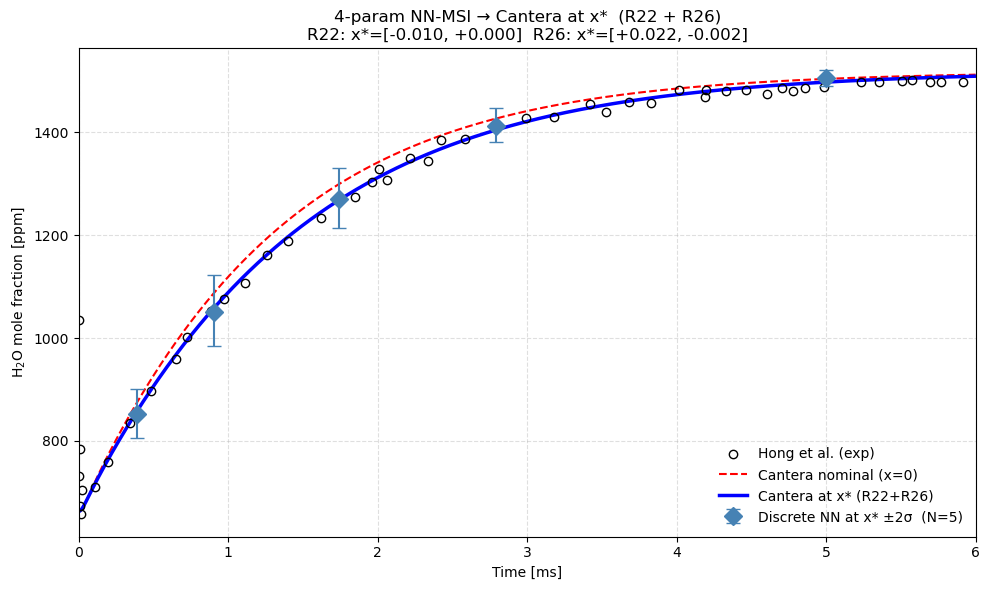

Saved: opt_r22r26_discrete_result.png


In [33]:
# ── Option A: Cantera full profile at x*, NN scatter at target times ──────────
print('Running Cantera at x* and x=0...')
y_opt_ct = cantera_profile(x_opt)
y_nom_ct = cantera_profile(np.zeros(INPUT_DIM))

raw_opt    = nn_raw(x_opt)
y_nn_ppm   = np.exp(raw_opt) * 1e6
y_nn_upper = y_nn_ppm * np.exp(+2 * pred_std)
y_nn_lower = y_nn_ppm * np.exp(-2 * pred_std)

t_ms = T_SIM * 1e3

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_exp * 1e3, y_exp * 1e6, 'o', mfc='none', mec='k',
        ms=6, label='Hong et al. (exp)', zorder=5)
ax.plot(t_ms, y_nom_ct * 1e6, 'r--', lw=1.5, label='Cantera nominal (x=0)')
ax.plot(t_ms, y_opt_ct * 1e6, 'b-',  lw=2.5, label='Cantera at x* (R22+R26)')
ax.errorbar(TARGET_TIMES * 1e3, y_nn_ppm,
            yerr=[y_nn_ppm - y_nn_lower, y_nn_upper - y_nn_ppm],
            fmt='D', color='steelblue', ms=9, lw=1.5, capsize=5, zorder=6,
            label=f'Discrete NN at x* ±2σ  (N={N_TARGETS})')

ax.set_xlabel('Time [ms]')
ax.set_ylabel(r'H$_2$O mole fraction [ppm]')
ax.set_xlim([0, 6])
ax.legend(loc='lower right', frameon=False)
ax.grid(True, ls='--', alpha=0.4)
ax.set_title(
    f'4-param NN-MSI → Cantera at x*  (R22 + R26)\n'
    f'R22: x*=[{x_opt[0]:+.3f}, {x_opt[1]:+.3f}]  '
    f'R26: x*=[{x_opt[2]:+.3f}, {x_opt[3]:+.3f}]')
plt.tight_layout()
plt.savefig(f'{OUT_PREFIX}_result.png', dpi=150)
plt.show()
print(f'Saved: {OUT_PREFIX}_result.png')

Computing Cantera FD Jacobian at x* (4 perturbation runs)...
  lnA_R22 done
  Ea_R22 done
  lnA_R26 done


/tmp/ipykernel_378608/1002714614.py:10: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn22.rate.low_rate = ct.Arrhenius(new_A_R22, NOMINAL_B_R22, new_Ea_R22)
/tmp/ipykernel_378608/1002714614.py:17: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn26.rate = ct.Arrhenius(new_A_R26, NOMINAL_B_R26, new_Ea_R26)
/tmp/ipykernel_378608/1002714614.py:21: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasReactor(gas, energy='on')
/tmp/ipykernel_378608/1002714614.py:27: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  profile[i] = reactor.thermo.X[h2o_idx]


  Ea_R26 done
Done.


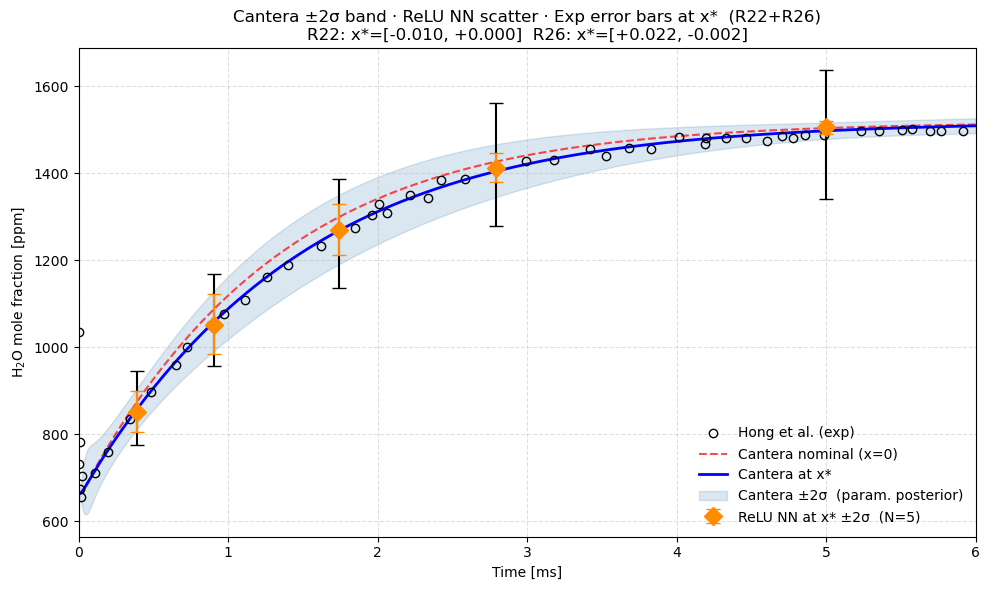

Saved: opt_r22r26_discrete_sigma_band.png


In [ ]:
# ── Cantera 2σ band: propagate posterior Σ* through Cantera FD Jacobian ───────
# Same as opt_r22_discrete_sigma_band.png but for the 4-param (R22+R26) case.
# Requires INPUT_DIM extra Cantera runs (4 perturbations).

# Exp values and error bars at target times
y_exp_tgt    = y_exp_at_targets * 1e6
y_exp_tgt_up = y_exp_tgt * np.exp(+2 * SIGMA_OB_LN)
y_exp_tgt_lo = y_exp_tgt * np.exp(-2 * SIGMA_OB_LN)

EPS_FD = 1e-3
print(f'Computing Cantera FD Jacobian at x* ({INPUT_DIM} perturbation runs)...')

log_y_base = np.log(np.clip(y_opt_ct, 1e-30, None))
J_ct_log   = np.zeros((TIME_STEPS, INPUT_DIM))

for k in range(INPUT_DIM):
    dx        = np.zeros(INPUT_DIM); dx[k] = EPS_FD
    y_plus    = cantera_profile(x_opt + dx)
    J_ct_log[:, k] = (np.log(np.clip(y_plus, 1e-30, None)) - log_y_base) / EPS_FD
    print(f'  {PARAM_NAMES[k]} done')

ct_logvar  = np.einsum('ti,ij,tj->t', J_ct_log, Sigma_star, J_ct_log)
ct_logstd  = np.sqrt(ct_logvar)
y_ct_upper = y_opt_ct * np.exp(+2 * ct_logstd)
y_ct_lower = y_opt_ct * np.exp(-2 * ct_logstd)
print('Done.')

# ── Combined plot ──────────────────────────────────────────────────────────────
act_name = 'ReLU' if 'relu' in os.path.basename(RESULT_PATH) else 'GELU'

fig, ax = plt.subplots(figsize=(10, 6))

# All experimental data as open black circles
ax.plot(t_exp * 1e3, y_exp * 1e6, 'o', mfc='none', mec='k',
        ms=6, label='Hong et al. (exp)', zorder=5)
# Error bars (whiskers only) at the 5 target times — no legend entry
ax.errorbar(TARGET_TIMES * 1e3, y_exp_tgt,
            yerr=[y_exp_tgt - y_exp_tgt_lo, y_exp_tgt_up - y_exp_tgt],
            fmt='none', ecolor='k', elinewidth=1.5, capsize=5, zorder=6,
            label='_nolegend_')

ax.plot(t_ms, y_nom_ct * 1e6, 'r--', lw=1.5, alpha=0.7,
        label='Cantera nominal (x=0)')
ax.plot(t_ms, y_opt_ct * 1e6, 'b-', lw=2, label='Cantera at x*')
ax.fill_between(t_ms,
                y_ct_lower * 1e6, y_ct_upper * 1e6,
                color='steelblue', alpha=0.20,
                label='Cantera ±2σ  (param. posterior)')

# NN predictions ±2σ (orange diamonds)
ax.errorbar(TARGET_TIMES * 1e3, y_nn_ppm,
            yerr=[y_nn_ppm - y_nn_lower, y_nn_upper - y_nn_ppm],
            fmt='D', color='darkorange', ms=9, lw=1.5, capsize=5, zorder=7,
            label=f'{act_name} NN at x* ±2σ  (N={N_TARGETS})')

ax.set_xlabel('Time [ms]')
ax.set_ylabel(r'H$_2$O mole fraction [ppm]')
ax.set_xlim([0, 6])
ax.legend(loc='lower right', frameon=False)
ax.grid(True, ls='--', alpha=0.4)
ax.set_title(
    f'Model predictions of optimized Cantera with optimized NN-RS for selected targets and respective experimental data\n'
    f'R22: x*=[{x_opt[0]:+.3f}, {x_opt[1]:+.3f}]  '
    f'R26: x*=[{x_opt[2]:+.3f}, {x_opt[3]:+.3f}]')
plt.tight_layout()
plt.savefig(f'{OUT_PREFIX}_sigma_band.png', dpi=150)
plt.show()
print(f'Saved: {OUT_PREFIX}_sigma_band.png')

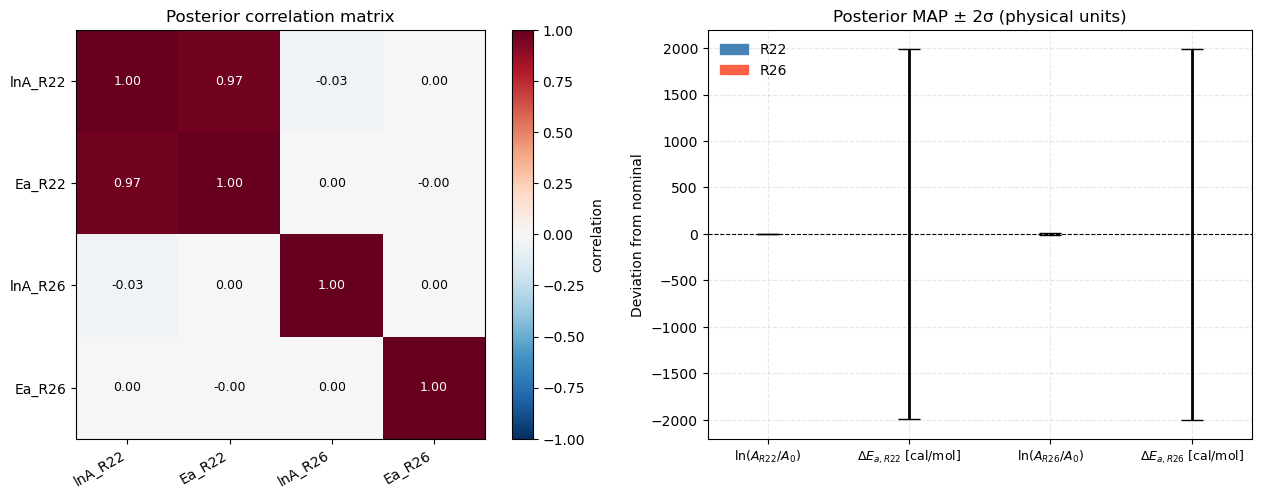

Saved: opt_r22r26_discrete_posterior.png


In [35]:
# ── Posterior correlation matrix (4×4) ───────────────────────────────────────
diag_std = np.sqrt(np.diag(Sigma_star))
Corr     = Sigma_star / np.outer(diag_std, diag_std)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Correlation matrix heat-map
ax = axes[0]
im = ax.imshow(Corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(INPUT_DIM)); ax.set_xticklabels(PARAM_NAMES, rotation=30, ha='right')
ax.set_yticks(range(INPUT_DIM)); ax.set_yticklabels(PARAM_NAMES)
for i in range(INPUT_DIM):
    for j in range(INPUT_DIM):
        ax.text(j, i, f'{Corr[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='white' if abs(Corr[i,j]) > 0.6 else 'black')
plt.colorbar(im, ax=ax, label='correlation')
ax.set_title('Posterior correlation matrix')

# Marginal posterior 2σ bars in physical units
ax = axes[1]
labels = [r'$\ln(A_{R22}/A_0)$', r'$\Delta E_{a,R22}$ [cal/mol]',
          r'$\ln(A_{R26}/A_0)$', r'$\Delta E_{a,R26}$ [cal/mol]']
centers = np.array([x_opt[0] * LN_F,
                    x_opt[1] * SIGMA_E,
                    x_opt[2] * LN_F,
                    x_opt[3] * SIGMA_E])
halfwidths = post_std_phys * 2   # 2σ

colors = ['steelblue', 'steelblue', 'tomato', 'tomato']
xi = np.arange(INPUT_DIM)
ax.bar(xi, centers, color=colors, alpha=0.7, width=0.5, label=['R22','R22','R26','R26'])
ax.errorbar(xi, centers, yerr=halfwidths, fmt='none', color='k', lw=2, capsize=8)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xticks(xi); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Deviation from nominal')
ax.set_title('Posterior MAP ± 2σ (physical units)')
ax.grid(True, ls='--', alpha=0.3)
# Custom legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='R22'), Patch(color='tomato', label='R26')],
          frameon=False)

plt.tight_layout()
plt.savefig(f'{OUT_PREFIX}_posterior.png', dpi=150)
plt.show()
print(f'Saved: {OUT_PREFIX}_posterior.png')

Direct Cantera 4-param optimization (FD Jacobian)...

  eval #  5  R22=[+0.000,+0.000]  R26=[+0.000,+0.000]

/tmp/ipykernel_378608/1002714614.py:10: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn22.rate.low_rate = ct.Arrhenius(new_A_R22, NOMINAL_B_R22, new_Ea_R22)
/tmp/ipykernel_378608/1002714614.py:17: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn26.rate = ct.Arrhenius(new_A_R26, NOMINAL_B_R26, new_Ea_R26)
/tmp/ipykernel_378608/1002714614.py:21: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasReactor(gas, energy='on')
/tmp/ipykernel_378608/1002714614.py:27: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  profile[i] = reactor.thermo.X[h2o_idx]



  eval # 10  R22=[-0.011,+0.008]  R26=[-0.004,-0.000]
  eval # 15  R22=[-0.012,+0.001]  R26=[-0.004,+0.000]
  eval # 20  R22=[-0.012,+0.001]  R26=[-0.004,+0.000]
  eval # 25  R22=[-0.012,+0.001]  R26=[-0.004,+0.000]
  eval # 30  R22=[-0.012,+0.001]  R26=[-0.004,+0.000]

Done. Total Cantera evals: 30
Converged: True

  x* Comparison: NN-MSI vs Direct Cantera
  Parameter         NN-MSI x*   Cantera x*      |Δ|
  ----------------------------------------------------
  lnA_R22           -0.010456    -0.011912   0.0015
  Ea_R22            +0.000453    +0.001038   0.0006
  lnA_R26           +0.021912    -0.004263   0.0262
  Ea_R26            -0.002426    +0.000407   0.0028

  Max |Δx*| = 0.0262  →  VALIDATED — surrogate found same optimum


/tmp/ipykernel_378608/943898100.py:103: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


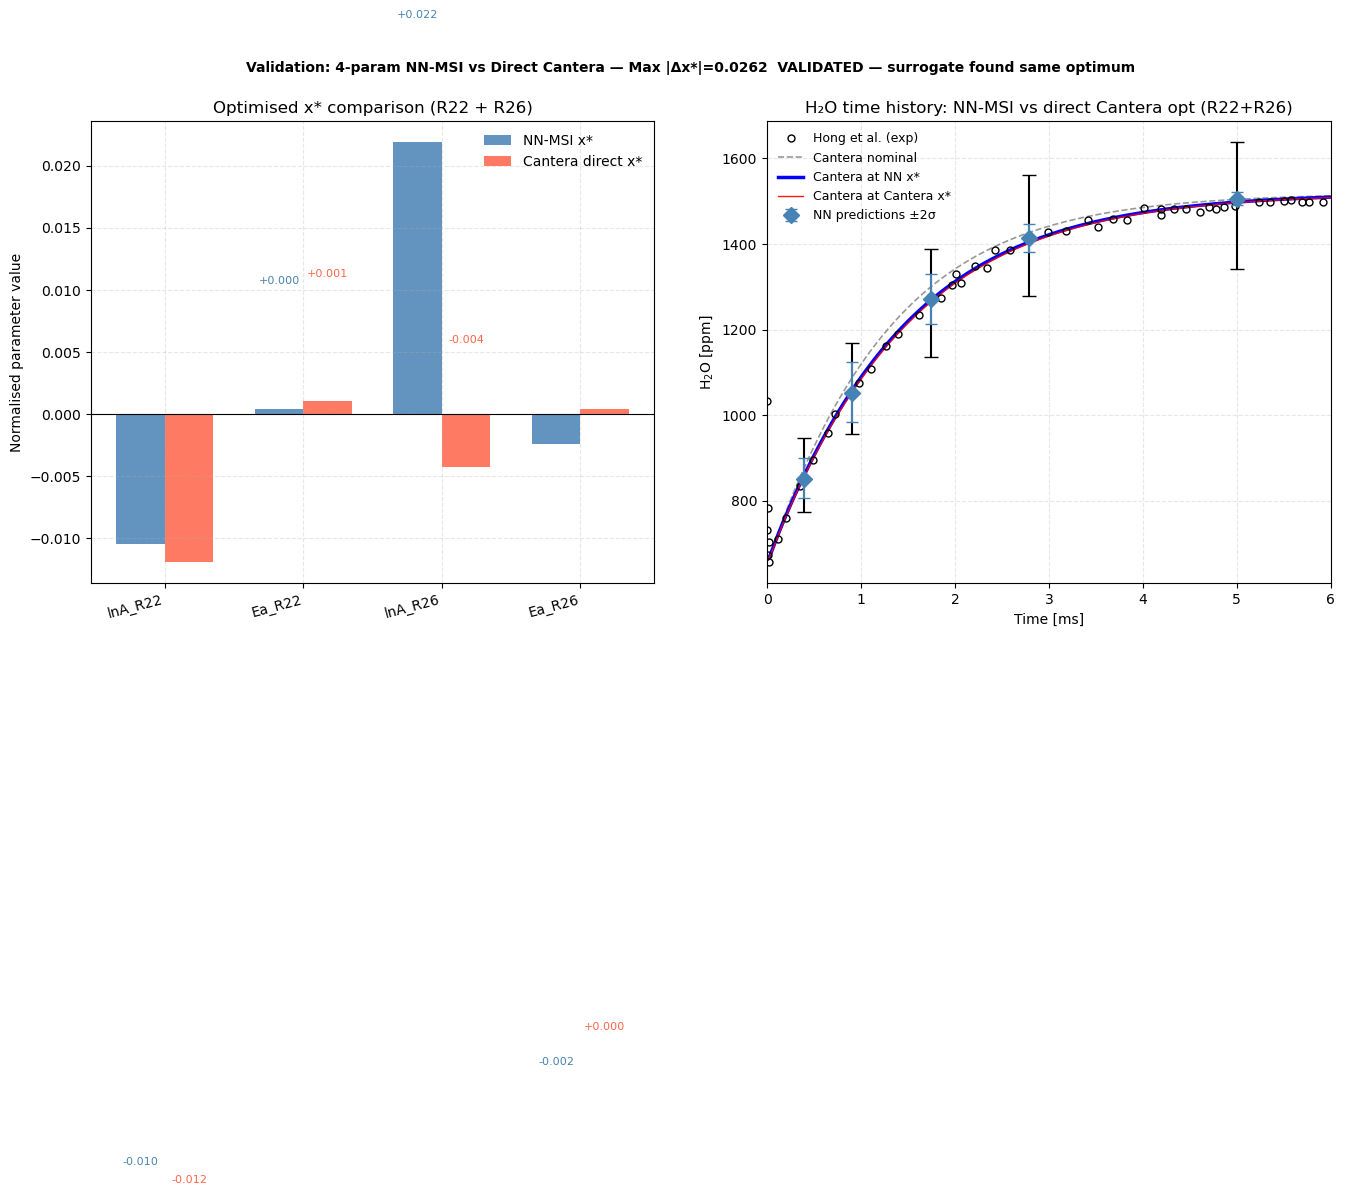

Saved: opt_r22r26_discrete_validation.png


In [36]:
# ── Optional: direct Cantera optimization for ground-truth validation ─────────
n_calls = [0]

def ct_objective(x_vec):
    n_calls[0] += 1
    if n_calls[0] % 5 == 0:
        print(f'  eval #{n_calls[0]:3d}  '
              f'R22=[{x_vec[0]:+.3f},{x_vec[1]:+.3f}]  '
              f'R26=[{x_vec[2]:+.3f},{x_vec[3]:+.3f}]')
    profile    = cantera_profile(x_vec)
    y_pred_at  = np.interp(TARGET_TIMES, T_SIM, profile)
    log_y_pred = np.log(np.clip(y_pred_at, NOISE_FLOOR, None))
    data_res   = (log_y_pred - log_y_exp) / SIGMA_OB_LN
    reg_res    = np.sqrt(LAMBDA) * np.asarray(x_vec)
    return np.concatenate([data_res, reg_res])

print('Direct Cantera 4-param optimization (FD Jacobian)...\n')
ct_result = least_squares(
    ct_objective, np.zeros(INPUT_DIM),
    method='trf',
    bounds=([-1.0]*INPUT_DIM, [1.0]*INPUT_DIM),
    diff_step=1e-3)
x_opt_ct = ct_result.x

print(f'\nDone. Total Cantera evals: {n_calls[0]}')
print(f'Converged: {ct_result.success}')

print('\n' + '='*65)
print('  x* Comparison: NN-MSI vs Direct Cantera')
print('='*65)
print(f'  {"Parameter":<14} {"NN-MSI x*":>12} {"Cantera x*":>12} {"|Δ|":>8}')
print(f'  {"-"*52}')
for name, xn, xc in zip(PARAM_NAMES, x_opt, x_opt_ct):
    print(f'  {name:<14} {xn:>+12.6f} {xc:>+12.6f} {abs(xn-xc):>8.4f}')
max_diff = np.max(np.abs(x_opt - x_opt_ct))
verdict  = 'VALIDATED — surrogate found same optimum' if max_diff < 0.05 else \
           'CHECK — surrogate diverged from true optimum'
print(f'\n  Max |Δx*| = {max_diff:.4f}  →  {verdict}')
print('='*65)

y_ct_direct = cantera_profile(x_opt_ct)

# Experimental values at target times for error bars
y_exp_tgt    = y_exp_at_targets * 1e6
y_exp_tgt_up = y_exp_tgt * np.exp(+2 * SIGMA_OB_LN)
y_exp_tgt_lo = y_exp_tgt * np.exp(-2 * SIGMA_OB_LN)

# NN predictions at x*
raw_opt    = nn_raw(x_opt)
y_nn_ppm   = np.exp(raw_opt) * 1e6
y_nn_upper = y_nn_ppm * np.exp(+2 * pred_std)
y_nn_lower = y_nn_ppm * np.exp(-2 * pred_std)

t_ms = T_SIM * 1e3

# ── Comparison plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: parameter bar chart
ax = axes[0]
w, xi = 0.35, np.arange(INPUT_DIM)
ax.bar(xi - w/2, x_opt,    w, color='steelblue', alpha=0.85, label='NN-MSI x*')
ax.bar(xi + w/2, x_opt_ct, w, color='tomato',    alpha=0.85, label='Cantera direct x*')
ax.axhline(0, color='k', lw=0.8)
for i, (xn, xc) in enumerate(zip(x_opt, x_opt_ct)):
    offset = 0.01 if xn >= 0 else -0.05
    ax.text(i - w/2, xn + offset, f'{xn:+.3f}', ha='center', fontsize=8, color='steelblue')
    ax.text(i + w/2, xc + offset, f'{xc:+.3f}', ha='center', fontsize=8, color='tomato')
ax.set_xticks(xi); ax.set_xticklabels(PARAM_NAMES, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Normalised parameter value')
ax.set_title('Optimised x* comparison (R22 + R26)')
ax.legend(frameon=False); ax.grid(True, ls='--', alpha=0.3)

# Right: H2O time history
ax = axes[1]

# Experimental circles + error bars at target times (no legend for error bars)
ax.plot(t_exp * 1e3, y_exp * 1e6, 'o', mfc='none', mec='k',
        ms=5, zorder=5, label='Hong et al. (exp)')
ax.errorbar(TARGET_TIMES * 1e3, y_exp_tgt,
            yerr=[y_exp_tgt - y_exp_tgt_lo, y_exp_tgt_up - y_exp_tgt],
            fmt='none', ecolor='k', elinewidth=1.5, capsize=5, zorder=6,
            label='_nolegend_')

ax.plot(t_ms, y_nom_ct    * 1e6, 'k--', lw=1.2, alpha=0.4, label='Cantera nominal')
ax.plot(t_ms, y_opt_ct    * 1e6, 'b-',  lw=2.5,            label='Cantera at NN x*')
ax.plot(t_ms, y_ct_direct * 1e6, 'r-',  lw=1.0, alpha=0.9, label='Cantera at Cantera x*')

ax.errorbar(TARGET_TIMES * 1e3, y_nn_ppm,
            yerr=[y_nn_ppm - y_nn_lower, y_nn_upper - y_nn_ppm],
            fmt='D', color='steelblue', ms=8, lw=1.5, capsize=4, zorder=7,
            label='NN predictions ±2σ')

ax.set_xlabel('Time [ms]'); ax.set_ylabel(r'H$_2$O [ppm]')
ax.set_xlim([0, 6]); ax.grid(True, ls='--', alpha=0.3)
ax.legend(frameon=False, fontsize=9)
ax.set_title('H₂O time history: NN-MSI vs direct Cantera opt (R22+R26)')

plt.suptitle(
    f'Validation: 4-param NN-MSI vs Direct Cantera — '
    f'Max |Δx*|={max_diff:.4f}  {verdict}',
    fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_PREFIX}_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_PREFIX}_validation.png')